In [2]:
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
hbar = 1973 #eV angstrom
m = .511*10**6 # eV/c^2
epsilon_0 = 1/(4*np.pi)
e =3.795 # (eV angstrom)^1/2
A = -hbar**2/(2*m)

In [4]:
# Constructing Hamiltonian matrix
def hamiltonian_matrix(n, dr, potential_values):
    
    """ To construct the hamiltonian matrix we need:
        n : (int) number of interior grid points
        dx : (float) grid spacing
        potential_values : (array like) potential energy value at every grid point
    """
    
    """ Kinetic Matrix """
    kinetic_matrix = np.zeros((n, n))
    for i in range(n):
        kinetic_matrix[i,i] = -2 
        if i+1 < n:
            kinetic_matrix[i+1,i]= kinetic_matrix[i,i+1] = 1 
    kinetic_energy = A*kinetic_matrix/dr**2
    
    """ Potential Energy Matrix """
    potential_energy = np.diag(potential_values)
    
    hamiltonian = kinetic_energy + potential_energy
    
    return hamiltonian

In [10]:
def screened_colulomb_potential(r, a):
    
    potential = -e**2 *np.exp(-r/a)/r

    return potential

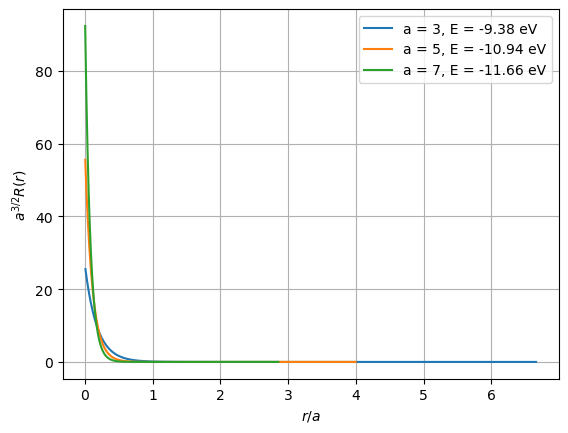

In [15]:
def solve_and_plot(r_max,interior_points, state_number,a):
    if interior_points <= 0:
        raise ValueError("interior_points must be positive.")

    if state_number < 0 or state_number >= interior_points:
        raise ValueError("Invalid state_number.")
    
    dr = r_max/(interior_points+1)

    r = np.linspace(dr, r_max-dr, interior_points)
    potential = screened_colulomb_potential(r, a)
    
    hamiltonian = hamiltonian_matrix(interior_points, dr, potential)
    
    energy, wavevector = np.linalg.eigh(hamiltonian)
    
    
    u = wavevector[:, state_number]
    if u[np.argmax(np.abs(u))] < 0:
        u = -u
    norm = np.sum(np.abs(u)**2)*dr
    u_norm = u / np.sqrt(norm)
    
    #calculating R
    R = u_norm/r
    return r/a, R*a**1.5, energy[state_number]
r = 20
a = [3,5,7]
for i in range(3):
    x, y, energy = solve_and_plot(r, 1000, 0, a[i])
    plt.plot(x, y, label=f"a = {a[i]}, E = {energy:.2f} eV")
plt.xlabel(r"$r/a$")
plt.ylabel(r"$a^{3/2}R(r)$")
plt.legend()
plt.grid(True)
plt.show()


